In [42]:
# 1. Setup and Imports
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [43]:
# 2. The Abstract Problem Interface
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [44]:
# 3. The Node Class
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def reconstruct_path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return self.reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [45]:
# 4. Helper Functions
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [46]:
# 5. Implementing the Grid Search Problem
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state

        for action_name, (dr, dc) in MOVES.items():
            next_state = (row + dr, col + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action_name)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1.0

In [47]:
# 6. Sample Drone Map
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [48]:
# 6
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [49]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
    color: str = "yellow",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path = list(path or [])
    path_set = set(path)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = color
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

    if path:
        xs = [col + 0.5 for row, col in path]
        ys = [row + 0.5 for row, col in path]
        ax.plot(xs, ys, color=color, linewidth=2.5)
        ax.scatter(xs[0], ys[0], color="red", s=70, zorder=3)
        ax.scatter(xs[-1], ys[-1], color="green", s=70, zorder=3)

    plt.show()

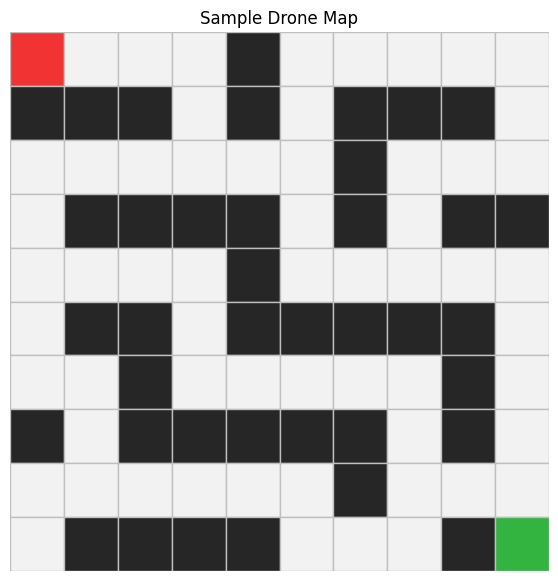

In [50]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [51]:
# 8. The Shared expand Method
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        current_state = node.state

        # for each action in problem.ACTIONS(s):
        for action in problem.actions(current_state):
            #     s_prime <- problem.RESULT(s, action)
            next_state = problem.result(current_state, action)
            #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
            cost = node.path_cost + problem.action_cost(
                current_state, action, next_state
            )
            #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
            yield Node(state=next_state, parent=node, action=action, path_cost=cost)
        raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [52]:
# 9. Breadth-First Search (BFS)
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algoritm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial initial_node from problem.initial_state().
        initial_node = Node(state=problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algoritm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )
        # 3. Create a deque frontier and add the initial initial_node.
        frontier = deque([initial_node])
        # 4. Create a reached set and add the initial state.
        reached = {problem.initial_state()}
        # Initialise tracking variables
        nodes_expanded = 0
        max_frontier_size = len(frontier)
        # 5. While frontier is not empty:
        while frontier:
            #       a. pop from the LEFT of the deque.
            initial_node = frontier.popleft()
            #       b. increment initial_nodes_expanded.
            nodes_expanded += 1

            #       c. expand the initial_node.
            #       d. for each child:
            for child in self.expand(problem, initial_node):
                #            i. if child is goal, return success.
                if problem.is_goal(child.state):
                    max_frontier_size = max(max_frontier_size, len(frontier))
                    return SearchResult(
                        algorithm=algoritm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )
                #           ii. if child.state is not in reached:
                if child.state not in reached:
                    #                  add child.state to reached.
                    reached.add(child.state)
                    #                  append child to frontier.
                    frontier.append(child)
            #       e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algoritm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

    def _expand(self, problem: Problem, node: Node):
        current_state = node.state
        for action in problem.actions(current_state):
            next_state = problem.result(current_state, action)
            cost = node.path_cost + problem.action_cost(
                current_state, action, next_state
            )
            yield Node(state=next_state, parent=node, action=action, path_cost=cost)

    # Patch the shared expand implementation for the already-defined search classes
    SearchAlgorithm.expand = _expand

    # raise NotImplementedError("Complete BreadthFirstSearch.search")

In [53]:
# 10. Depth-First Search (DFS)
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        initial_node = Node(state=problem.initial_state())

        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]
        # 4. Use a reached set.
        reached = {initial_node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        # 5. While frontier is not empty:
        while frontier:
            #       a. pop from the end of the list.

            initial_node = frontier.pop()
            #       b. increment nodes_expanded.

            nodes_expanded += 1
            #       c. expand the node.
            children = list(self.expand(problem, initial_node))
            for child in reversed(children):
                state = child.state

                if problem.is_goal(state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(frontier),
                    )

                if state not in reached:
                    reached.add(state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))
        # return failure

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

    # raise NotImplementedError("Complete DepthFirstSearch.search")

In [54]:
# 11. Depth-Limited Search (DLS) path
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(state=problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(problem=problem, node=initial_node, limit=limit, metrics=metrics, current_stack_size=1,)

        return SearchResult(algorithm=algorithm, status=status, solution=solution, nodes_expanded=metrics["nodes_expanded"], max_frontier_size=metrics["max_stack_size"], reached_count=0, limit=limit,)

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)

        if problem.is_goal(node.state):
            return node, "success"

        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue

            result, status = self._recursive_dls(problem=problem, node=child, limit=limit, metrics=metrics, current_stack_size=current_stack_size + 1,
            )

            if status == "success":
                return result, "success"

            if status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"

        return None, "failure"


In [ ]:
# 12. Iterative Deepening Search (IDS)
#TODO 9
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded = 0
        max_frontier_size = 0

        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            iteration_log.append(result)
            total_nodes_expanded += result.nodes_expanded
            max_frontier_size = max(max_frontier_size, result.max_frontier_size)

            if result.status == "success":
                return SearchResult(algorithm=algorithm, status="success", solution=result.solution, nodes_expanded=total_nodes_expanded, max_frontier_size=max_frontier_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

            if result.status == "failure":
                return SearchResult(algorithm=algorithm, status="failure", solution=None, nodes_expanded=total_nodes_expanded, max_frontier_size=max_frontier_size, reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

        return SearchResult(algorithm=algorithm, status="cutoff", solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

In [56]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()


results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,2
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


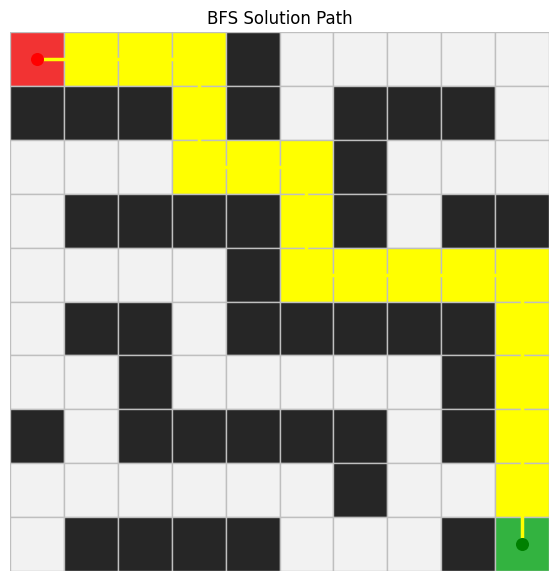

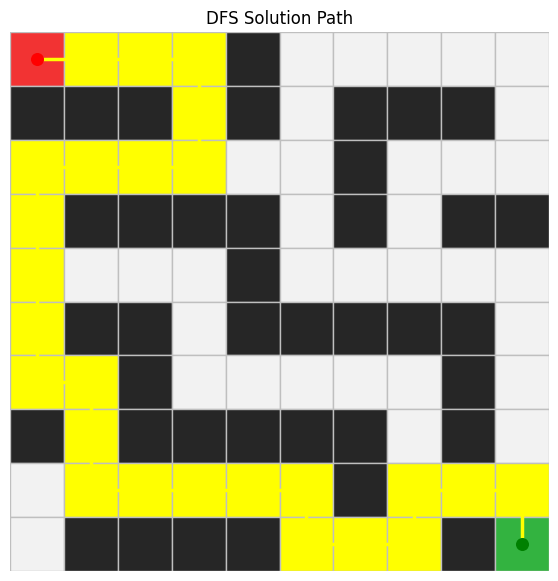

DLS Solution Path: no solution found


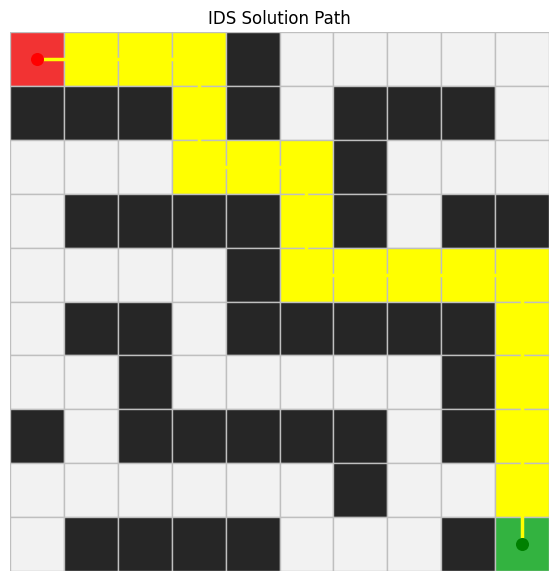

In [57]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]
dls_result = results[2]
ids_result = results[3]

for result, label in [
    (bfs_result, "BFS Solution Path"),
    (dfs_result, "DFS Solution Path"),
    (dls_result, "DLS Solution Path"),
    (ids_result, "IDS Solution Path"),
]:
    if result.solution is not None:
        path = reconstruct_path(result.solution)
        plot_path(
            sample_grid,
            start,
            goal,
            path=path,
            title=label,
            color="yellow",
        )
    else:
        print(f"{label}: no solution found")

In [58]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    
]

custom_start_1 = (2, 2)
custom_goal_1 = (5, 9)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,10,10.0,30,5,32
1,DFS,success,NaN,24,24.0,27,7,5
2,DLS,success,20.0,14,14.0,30,21,0
3,IDS,success,10.0,10,10.0,162,11,0


Visaul for Custom Map 1


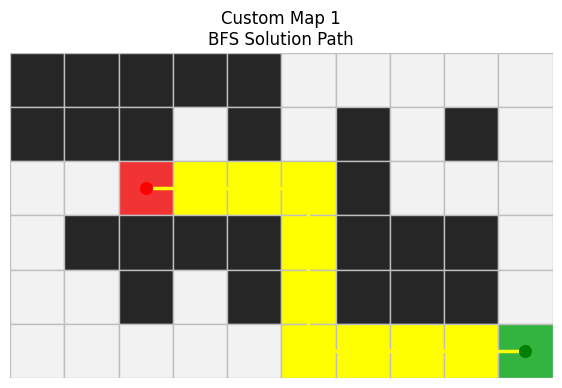

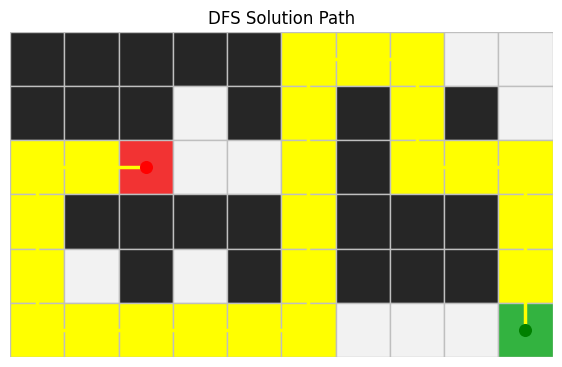

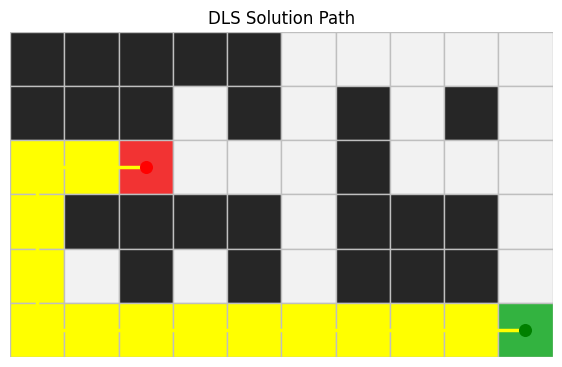

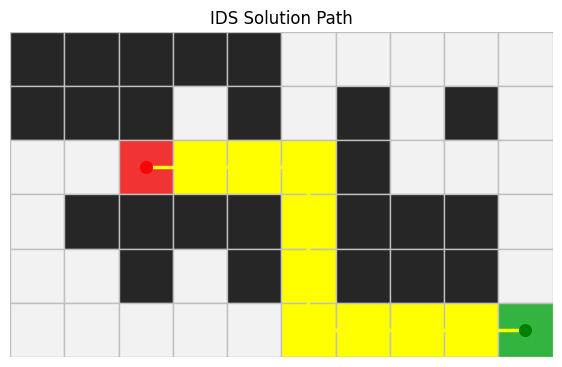

In [59]:
# Visualise solution paths for Custom Map 1
print("Visaul for Custom Map 1")
for result, label in [
    (custom_results_1[0], "Custom Map 1\nBFS Solution Path"),
    (custom_results_1[1], "DFS Solution Path"),
    (custom_results_1[2], "DLS Solution Path"),
    (custom_results_1[3], "IDS Solution Path"),
]:
    if result.solution is not None:
        path = reconstruct_path(result.solution)
        plot_path(
            custom_grid_1,
            custom_start_1,
            custom_goal_1,
            path=path,
            title=label,
            color="yellow",
        )
    else:
        print(f"{label}: no solution found")

In [60]:
# TODO 0:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0]
    
]

custom_start_2 = (0, 0)
custom_goal_2 = (5, 6)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)



,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,11,11.0,34,5,35
1,DFS,success,NaN,21,21.0,21,9,9
2,DLS,success,20.0,19,19.0,82,21,0
3,IDS,success,11.0,11,11.0,1275,12,0


Custom Map 2 Results:


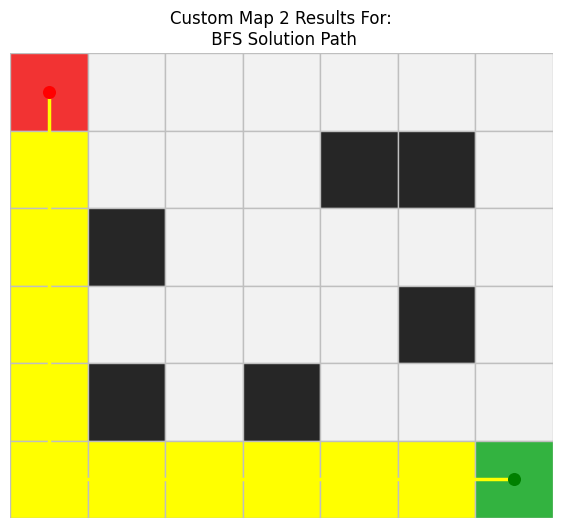

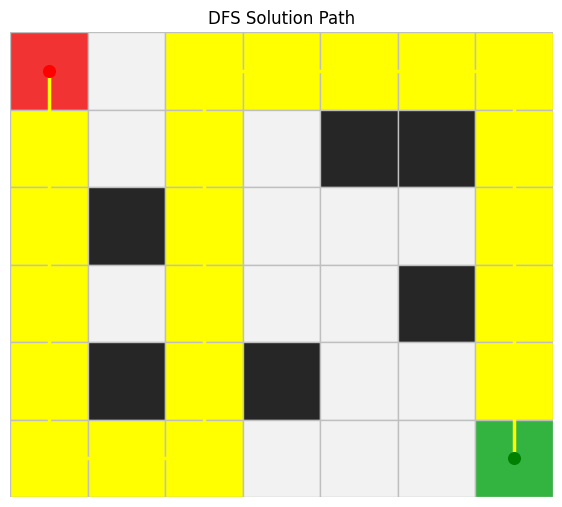

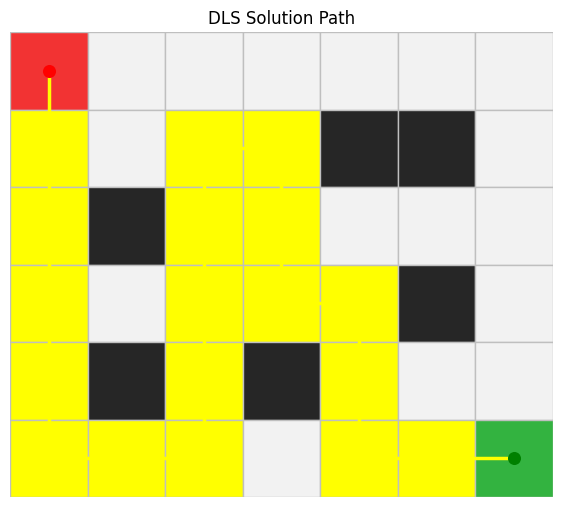

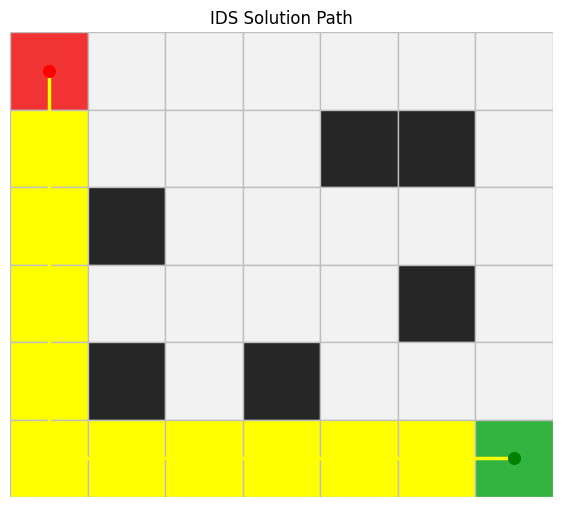

In [61]:
# Visualise solution paths for Custom Map 2
print("Custom Map 2 Results:")
for result, label in [
    (custom_results_2[0], "Custom Map 2 Results For:\n BFS Solution Path"),
    (custom_results_2[1], "DFS Solution Path"),
    (custom_results_2[2], "DLS Solution Path"),
    (custom_results_2[3], "IDS Solution Path"),
]:
    if result.solution is not None:
        path = reconstruct_path(result.solution)
        plot_path(
            custom_grid_2,
            custom_start_2,
            custom_goal_2,
            path=path,
            title=label,
            color="yellow",
        )
    else:
        print(f"{label}: no solution found")